In [1]:
import sys, os
dir = os.getcwd()

import copy
import json
from enum import Enum
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import clear_output
import plotly.graph_objects as go
import networkx as nx

In [2]:
IMGBB_API_KEY = '8ae6cb592a734c0c3593f1934b9d90a9'
OPENAI_API_KEY = 'YOUR_OPENAI_KEY'

In [3]:
import base64
import requests

def upload_im(im, key):
    url = "https://api.imgbb.com/1/upload"
    payload = {
        'key': key,
        'image': base64.b64encode(im)
    }
    response = requests.post(url, data=payload)
    if response.status_code == 200:
        return response.json()['data']['url']
    else:
        raise Exception(f'[{response.status_code}] Failed to upload image.')

In [4]:
from openai import OpenAI

client = OpenAI(api_key=OPENAI_API_KEY)

class Chat:

    class Entry:
        def __init__(self, role: str, text: str = "", im = None, im_url: str = ''):
            self.role = role
            self.text = text
            if im_url:
                self.im_url = im_url
            elif im:
                self.im_url = upload_im(im, IMGBB_API_KEY)
            else:
                self.im_url = ''

        def to_dict(self) -> dict:
            content = []

            if self.text:
                content.append({
                    'type': 'text',
                    'text': self.text
                })

            if self.im_url:
                content.append({
                    'type': 'image_url',
                    'image_url': {
                        'url': self.im_url
                    }
                })

            obj = {
                'role': self.role,
                'content': content
            }

            return obj

    def __init__(self, client, model='gpt-4o-mini'):
        self.model = model
        self.client = client

    def __call__(self, input: list[Entry] = [], json: bool = False):
        chat = self.client.chat.completions.create(
            model=self.model,
            messages=[entry.to_dict() for entry in input],
            response_format={'type': 'json_object' if json else 'text'}
        )
        return chat.choices[0].message.content

In [5]:
def get_im(dir):
    with open(dir, "rb") as im: 
        return im.read()

def get_imi_dir(dir) -> list[str]:
    valid_extensions = {'.png', '.jpg', '.jpeg'}
    files = [f for f in os.listdir(dir) if os.path.splitext(f)[1].lower() in valid_extensions]
    files.sort()
    return [os.path.join(dir, f) for f in files]

In [6]:
DATA_DIR = 'data/transcript_6'

keyframes = get_imi_dir(f'{dir}/{DATA_DIR}/keyframes')

# TODO: Automate language extraction from data

language = """
Coach: So in this situation,you want to realize that you can make a move forward.So after your team passes the ball to you,you want to pass it back immediately.
Coach: Now,you want to get him behind these men in order to penetrate the line of defense over here. And then, recieve the ball.
"""

In [7]:
inference_instructions = """
The user inputs a series of top-down keyframes (in chronological order) from a video where a soccer coach instructs on how to play under a particular scenario as if they were a player.
You're tasked to reason about the keyframes in the context of the coach's explanation and demonstrations and build a series of tasks for the player.
We would like to learn such behaviour from the coach for another player replacing them so tasks should be defined for the coach or hypothetical player replacing the coach.

Tasks are defined in the context of a finite state machine were each task denotes a node with a termination condition, i.e., the condition under which the task will be marked as terminated so the state can change,
and edges are preconditions, i.e., the condition under which a following task should be triggered and the state changes from the previous task.

You response return must be a json with format 

{
    'nodes': [
        {
            'id': int,  // Unique identifier for the task node
            'action': str,  // 'wait', 'move', 'pass'
            'task': str,  // Description of the action
            'termination': str,  // Condition under which the task terminates
            'keyframe': int  // Keyframe index where the task ends
        }
    ],
    "edges": [
        {
            'id': int,  // Unique identifier for the condition edge
            'from': int,  // ID of the previous node
            'to': int,  // ID of the next node
            'precondition': str  // Condition under which the transition happens
            'keyframe': int  // Keyframe index where the task ends
        }
    ]
}

Note that careful frame selection is important for accurate behavior learning (e.g. when we learn when to make a pass we want to learn from the frame where the pass was made and both players are at the expected locations).
The subtasks should be ordered chronologically too.
"""

entries = [
    Chat.Entry(role='system', text=inference_instructions),
    Chat.Entry(role='user', text=language)
] + [Chat.Entry(role='user', text=f'Frame index: {idx}', im=get_im(im_dir)) for idx, im_dir in enumerate(keyframes)]

chat = Chat(client, model='o1')
response = json.loads(chat(entries, json=True))
print('Inference done.')

Inference done.


In [8]:
dummy = {
    "nodes": [
        {
            "id": 1,
            "action": "wait",
            "task": "Wait in position for teammates to move into optimal passing lanes.",
            "termination": "Teammates are in position.",
            "keyframe": 5
        },
        {
            "id": 2,
            "action": "move",
            "task": "Dribble forward to attract defenders and create space.",
            "termination": "Defenders commit to pressing.",
            "keyframe": 12
        },
        {
            "id": 3,
            "action": "pass",
            "task": "Make a through pass to the advancing teammate.",
            "termination": "Ball leaves foot and is directed towards the teammate.",
            "keyframe": 18
        },
        {
            "id": 4,
            "action": "wait",
            "task": "Observe the teammate's reception and react accordingly.",
            "termination": "Teammate controls the ball.",
            "keyframe": 22
        },
        {
            "id": 5,
            "action": "move",
            "task": "Move into supporting position for a potential return pass.",
            "termination": "Reach the supporting position.",
            "keyframe": 28
        }
    ],
    "edges": [
        {
            "from": 1,
            "to": 2,
            "precondition": "Teammates are in position.",
            "keyframe": 5
        },
        {
            "from": 2,
            "to": 3,
            "precondition": "Defenders commit to pressing.",
            "keyframe": 12
        },
        {
            "from": 3,
            "to": 4,
            "precondition": "Ball leaves foot and is directed towards the teammate.",
            "keyframe": 18
        },
        {
            "from": 4,
            "to": 5,
            "precondition": "Teammate controls the ball.",
            "keyframe": 22
        }
    ]
}


In [9]:
class Action(Enum):

    wait = 'wait'
    move = 'move'
    deliver = 'pass'
    unknown = 'unknown'

    def __repr__(self):
        return f'Action.{self.value}'

class InferredTask:
    def __init__(self, id: int, action: Action, task: str, termination: str, keyframe: int):

        self.id = id
        self.action = action

        self.task = task
        self.termination = termination
        self.keyframe = keyframe

        self.original = copy.deepcopy(self)

    def __repr__(self):
        return f'[{self.action.value.capitalize()}] {self.task}'

    @classmethod
    def from_dict(cls, data: dict):

        id = data.get('id', None)
        action = Action(data.get('action', Action.unknown))

        task = data.get('task', '')
        termination = data.get('termination', '')
        keyframe = data.get('keyframe', -1)

        return cls(id, action, task, termination, keyframe)
    
class InferredTransition:
    def __init__(self, id: int, from_id: int, to_id: int, precondition: str, keyframe: int):
        
        self.id = id

        self.from_id = from_id
        self.to_id = to_id

        self.precondition = precondition
        self.keyframe = keyframe

    @classmethod
    def from_dict(cls, data):

        id = data.get('id', None)
        from_id = data.get('from', None)
        to_id = data.get('to', None)

        precondition = data.get('precondition', '')
        keyframe = data.get('keyframe', -1)

        return cls(id, from_id, to_id, precondition, keyframe)

class Behavior:
    def __init__(self):
        self.nodes = []
        self.edges = []

    def add_node(self, task: InferredTask):
        self.nodes.append(task)

    def add_edge(self, trans: InferredTransition):
        self.edges.append(trans)

    @classmethod
    def from_dict(cls, data):
        result = cls()
        for n in data.get('nodes', []):
            result.add_node(InferredTask.from_dict(n))
        for e in data.get('edges', []):
            result.add_edge(InferredTransition.from_dict(e))
        return result
    
    def show(self):
        G = nx.DiGraph()

        for n in self.nodes:
            G.add_node(n.id, label=f'[{n.action.value.capitalize()}]\n{n.task}')

        for e in self.edges:
            G.add_edge(e.from_id, e.to_id, label=e.precondition)

        pos = nx.kamada_kawai_layout(G)
        labels = nx.get_node_attributes(G, "label")

        plt.figure(figsize=(10, 6))
        nx.draw(G, pos, with_labels=True, labels=labels, node_color="skyblue", edge_color="black", node_size=2000, font_size=10)
        edge_labels = nx.get_edge_attributes(G, "label")
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
        plt.title("Infered Behaviour")
        plt.show()


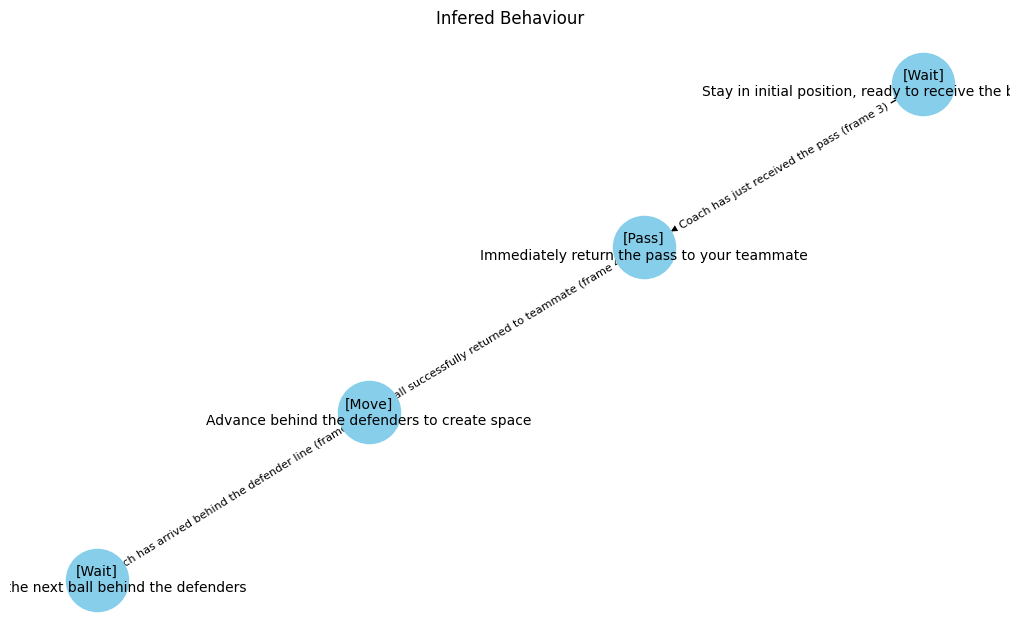

In [10]:
infered_behaviour = Behavior.from_dict(response)
infered_behaviour.show()

In [11]:
modifications = []
for i, t in enumerate(infered_behaviour.nodes):

    print(f'{i + 1}/{len(infered_behaviour.nodes)}')
    print()
    print(t)
    print('Termination:', t.termination)
    print('Infered keyframe:', t.keyframe)
    
    plt.imshow(Image.open(keyframes[t.keyframe]))
    plt.axis('off')
    plt.show()

    manual_keyframe = input('Type the index (0-indexed) of keyframe to modify it or return to continue.')
    if manual_keyframe != '' and int(manual_keyframe) < len(keyframes):
        t.keyframe = manual_keyframe
        modifications += [f'[Task {i + 1}] Modified keyframe: {t.original.keyframe} -> {t.keyframe}']

    clear_output(wait=False)

if not len(modifications):
    print('No modifications.')
for mod in modifications:
    print(mod)

No modifications.


In [12]:
from synth_utils import Demo

In [ ]:
class Action:
    def __init__(self, task: InferredTask):

        # TODO: Add ID?

        self.task = task

    def learn(self, demo):
        pass

    def to_dict(self):
        pass

    @classmethod
    def from_task(cls, tasks, actionAPI) -> list['Action']:

        # TODO: Write to adapt to API

        if not isinstance(tasks, list):
            tasks = [tasks]

        instructions = """
        
        """

        tasks = {str(i): t for i, t in enumerate(tasks)}
        tasks_info = '\n\n'.join(f'Task {i}:\n{str(t)}' for i, t in tasks)

        chat = Chat(client, model='gpt-4o')
        response = chat([
            Chat.Entry('system', text=instructions),
            Chat.Entry('user', tasks_info)
        ], json=True)

        result = []
        actions = json.loads(response).get('actions', [])
        for a in actions:
            id = a.get('id', None)
            task = tasks.get(id, None)
            api = a.get('actionAPI', None)
            if api in actionAPI:
                result += [actionAPI[id](task)]
            else:
                result += [cls(task)]

        return result


In [25]:
import os
import cv2
import base64
import tiktoken
import numpy as np

def extract_frames_from_video(video_path, output_dir=None, time_step=0.2, scale_factor=1.0):

    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")
        
    if output_dir is None:
        video_dir = os.path.dirname(video_path)
        video_name = os.path.splitext(os.path.basename(video_path))[0]
        output_dir = os.path.join(video_dir, f"{video_name}_frames")
    
    os.makedirs(output_dir, exist_ok=True)
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Error opening video file: {video_path}")
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = int(fps * time_step)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Get original dimensions
    original_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Calculate new dimensions
    new_width = int(original_width * scale_factor)
    new_height = int(original_height * scale_factor)
    
    frame_paths = []
    frame_count = 0
    current_frame = 0
    total_tokens = 0
    
    # Initialize tokenizer
    encoding = tiktoken.get_encoding("cl100k_base")  # GPT-4 encoding
    
    while current_frame < total_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, current_frame)
        ret, frame = cap.read()
        
        if not ret:
            break
            
        # Resize frame if scale_factor is not 1.0
        if scale_factor != 1.0:
            frame = cv2.resize(frame, (new_width, new_height), interpolation=cv2.INTER_AREA)
        
        frame_path = os.path.join(output_dir, f"frame_{frame_count:04d}.jpg")
        cv2.imwrite(frame_path, frame)
        frame_paths.append(frame_path)
        
        # Calculate tokens for this frame
        # Convert frame to base64 string (similar to how it would be sent to API)
        _, buffer = cv2.imencode('.jpg', frame)
        base64_string = base64.b64encode(buffer).decode('utf-8')
        frame_tokens = len(encoding.encode(base64_string))
        total_tokens += frame_tokens
        
        frame_count += 1
        current_frame += frame_interval
    
    cap.release()
    
    print(f"Successfully extracted {frame_count} frames to {output_dir}")
    print(f"Time interval between frames: {time_step} seconds")
    print(f"Frame dimensions: {new_width}x{new_height} (scale factor: {scale_factor})")
    print(f"Total estimated tokens for all frames: {total_tokens}")
    print(f"Average tokens per frame: {total_tokens // frame_count if frame_count > 0 else 0}")
    
    return frame_paths, total_tokens

extract_frames_from_video(
    '/Users/jdiazchao/Documents/narrated_demo/narrated_demo/v2/data2/transcript_6/demonstration0/videos/participant0_demo0_segment0.mp4',
    time_step=2.0,
    scale_factor = 0.4
)

Successfully extracted 20 frames to /Users/jdiazchao/Documents/narrated_demo/narrated_demo/v2/data2/transcript_6/demonstration0/videos/participant0_demo0_segment0_frames
Time interval between frames: 2.0 seconds
Frame dimensions: 432x768 (scale factor: 0.4)
Total estimated tokens for all frames: 913366
Average tokens per frame: 45668


(['/Users/jdiazchao/Documents/narrated_demo/narrated_demo/v2/data2/transcript_6/demonstration0/videos/participant0_demo0_segment0_frames/frame_0000.jpg',
  '/Users/jdiazchao/Documents/narrated_demo/narrated_demo/v2/data2/transcript_6/demonstration0/videos/participant0_demo0_segment0_frames/frame_0001.jpg',
  '/Users/jdiazchao/Documents/narrated_demo/narrated_demo/v2/data2/transcript_6/demonstration0/videos/participant0_demo0_segment0_frames/frame_0002.jpg',
  '/Users/jdiazchao/Documents/narrated_demo/narrated_demo/v2/data2/transcript_6/demonstration0/videos/participant0_demo0_segment0_frames/frame_0003.jpg',
  '/Users/jdiazchao/Documents/narrated_demo/narrated_demo/v2/data2/transcript_6/demonstration0/videos/participant0_demo0_segment0_frames/frame_0004.jpg',
  '/Users/jdiazchao/Documents/narrated_demo/narrated_demo/v2/data2/transcript_6/demonstration0/videos/participant0_demo0_segment0_frames/frame_0005.jpg',
  '/Users/jdiazchao/Documents/narrated_demo/narrated_demo/v2/data2/transcrip